# 03 - Expériences QMKL (Quantum Multiple Kernel Learning)

Ce notebook implémente et compare les différentes stratégies QMKL.

**Méthodes comparées :**
- Single Kernel baseline
- QMKL Average (poids égaux)
- QMKL Centered Alignment
- QMKL SDP Alignment
- QMKL Projection
- QMKL Bayesian Optimization (BO-MKQSVM)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from sklearn.model_selection import train_test_split

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.kernels import build_feature_map, build_quantum_kernel, compute_kernel_matrix
from src.kernels.feature_maps import get_feature_map_library
from src.mkl import MultipleKernelCombiner
from src.mkl.bayesian_optimizer import BayesianKernelOptimizer
from src.models import QSVM
from src.evaluation import compute_all_metrics
from src.evaluation.visualization import (
    plot_weights, plot_comparison, plot_kernel_heatmap, plot_roc_curve
)

%matplotlib inline

## 1. Préparation des données et calcul des kernels

In [2]:
DATASET = 'german_credit'
N_QUBITS = 6
N_SAMPLES = 200  # Réduit pour rapidité en simulation

X, y = load_dataset(DATASET, n_samples=N_SAMPLES, random_state=42)

reducer = FeatureReducer(n_components=N_QUBITS)
scaler = QuantumScaler(feature_range=(0, 2))
X_processed = scaler.fit_transform(reducer.fit_transform(X))

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.33, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (134, 6), Test: (66, 6)


In [3]:
# Calculer toutes les kernel matrices
fm_library = get_feature_map_library(N_QUBITS)
print(f'Nombre de kernels dans la librairie: {len(fm_library)}')

kernel_matrices_train = []
kernel_matrices_test = []
kernel_names = []

for label, fm in fm_library:
    print(f'  Computing {label}...')
    qk = build_quantum_kernel(fm, kernel_type='fidelity')
    K_tr = compute_kernel_matrix(qk, X_train)
    K_te = compute_kernel_matrix(qk, X_train, X_test)
    kernel_matrices_train.append(K_tr)
    kernel_matrices_test.append(K_te)
    kernel_names.append(label)

print(f'\nDone! {len(kernel_matrices_train)} kernel matrices computed.')

Nombre de kernels dans la librairie: 12
  Computing Z_a1.4...
  Computing Z_a2.0...
  Computing Z_a14...
  Computing Z_a20...
  Computing ZZ_a2.0...
  Computing ZZ_a20...
  Computing pauli_XZ_a0.4...
  Computing pauli_XZ_a4.0...
  Computing pauli_a0.6...
  Computing pauli_a6.0...
  Computing pauli_YXX_a0.6...
  Computing pauli_YXX_a6.0...

Done! 12 kernel matrices computed.


## 2. Comparaison des méthodes MKL

In [4]:
methods = ['average', 'centered', 'projection']
all_results = {}
all_weights = {}

for method in methods:
    print(f'\n--- {method.upper()} ---')
    combiner = MultipleKernelCombiner(method=method)
    K_train_combined = combiner.fit_combine(kernel_matrices_train, y_train)
    
    weights = combiner.get_weights()
    all_weights[method] = weights
    
    # Combine test kernels
    K_test_combined = np.zeros_like(kernel_matrices_test[0])
    for w, K in zip(weights, kernel_matrices_test):
        K_test_combined += w * K
    
    # Train & evaluate
    svm = QSVM(C=1.0)
    svm.fit(K_train_combined, y_train)
    y_pred = svm.predict(K_test_combined)
    y_proba = svm.predict_proba(K_test_combined)
    
    metrics = compute_all_metrics(y_test, y_pred, y_proba)
    all_results[f'QMKL-{method}'] = metrics
    print(f'  ROC-AUC: {metrics.get("roc_auc", "N/A"):.4f}')
    print(f'  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  Top-3 kernels: {np.argsort(weights)[-3:][::-1]}')


--- AVERAGE ---
  ROC-AUC: 0.7413
  Accuracy: 0.7121
  Top-3 kernels: [11 10  9]

--- CENTERED ---
  ROC-AUC: 0.6707
  Accuracy: 0.7121
  Top-3 kernels: [ 8  5 11]

--- PROJECTION ---
  ROC-AUC: 0.7076
  Accuracy: 0.7121
  Top-3 kernels: [6 9 3]


## 3. Bayesian Optimization (BO-MKQSVM)

In [5]:
print('Running Bayesian Optimization (this may take a few minutes)...')
bo = BayesianKernelOptimizer(n_calls=30, n_initial_points=10)
bo_weights, bo_C = bo.optimize(kernel_matrices_train, y_train)

print(f'Best C: {bo_C:.4f}')
print(f'Best weights: {bo_weights}')

# Combine and evaluate
K_train_bo = sum(w * K for w, K in zip(bo_weights, kernel_matrices_train))
K_test_bo = sum(w * K for w, K in zip(bo_weights, kernel_matrices_test))

svm_bo = QSVM(C=bo_C)
svm_bo.fit(K_train_bo, y_train)
y_pred_bo = svm_bo.predict(K_test_bo)
y_proba_bo = svm_bo.predict_proba(K_test_bo)

metrics_bo = compute_all_metrics(y_test, y_pred_bo, y_proba_bo)
all_results['QMKL-BO'] = metrics_bo
all_weights['bayesian'] = bo_weights

print(f'ROC-AUC: {metrics_bo.get("roc_auc", "N/A"):.4f}')
print(f'Accuracy: {metrics_bo["accuracy"]:.4f}')

Running Bayesian Optimization (this may take a few minutes)...
Best C: 9.5935
Best weights: [0.14485202 0.02313862 0.14485202 0.1381068  0.         0.03824749
 0.02775368 0.03121539 0.14485202 0.04675408 0.11976735 0.14046053]
ROC-AUC: 0.7620
Accuracy: 0.7273


## 4. Visualisation des résultats

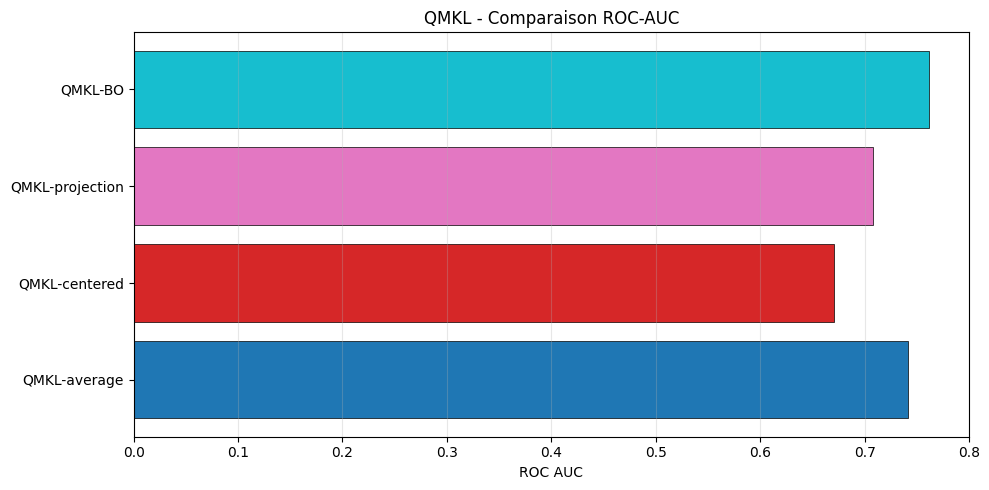

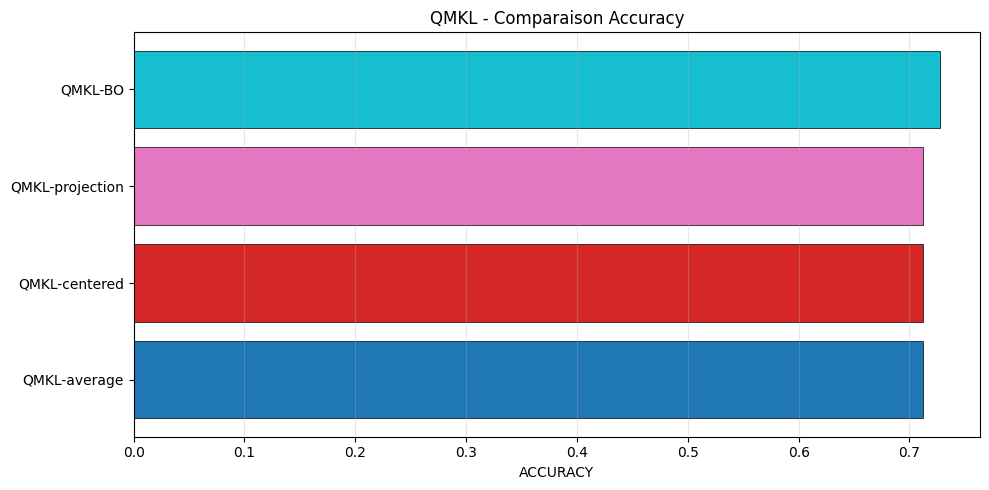

In [6]:
# Comparaison des méthodes
plot_comparison(all_results, metric='roc_auc', title='QMKL - Comparaison ROC-AUC')
plot_comparison(all_results, metric='accuracy', title='QMKL - Comparaison Accuracy')

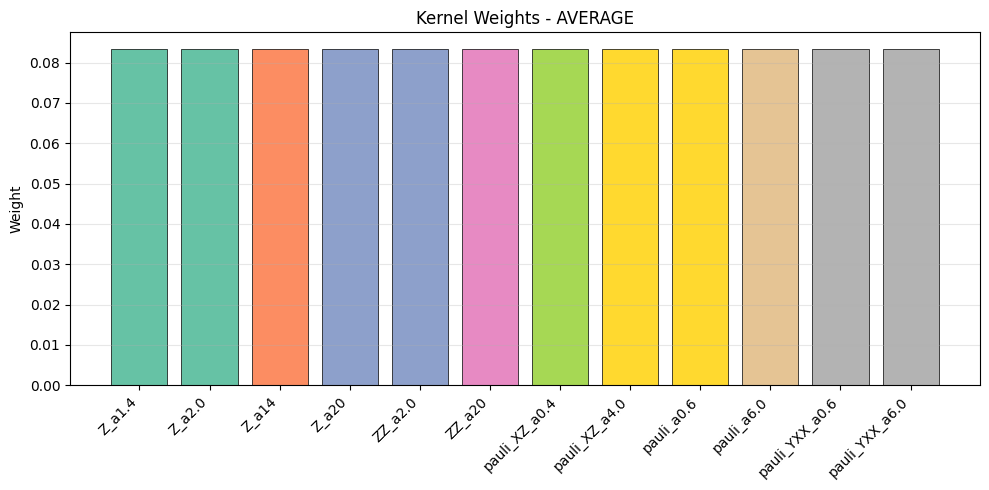

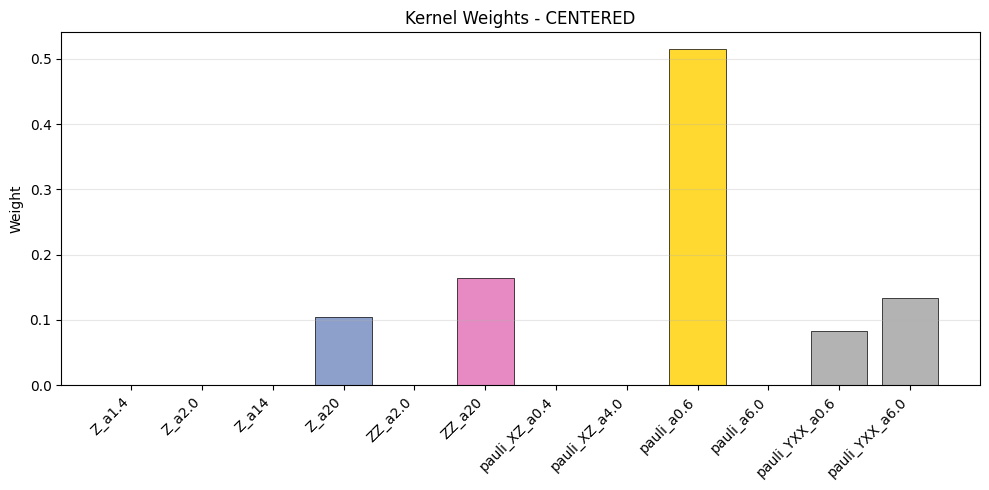

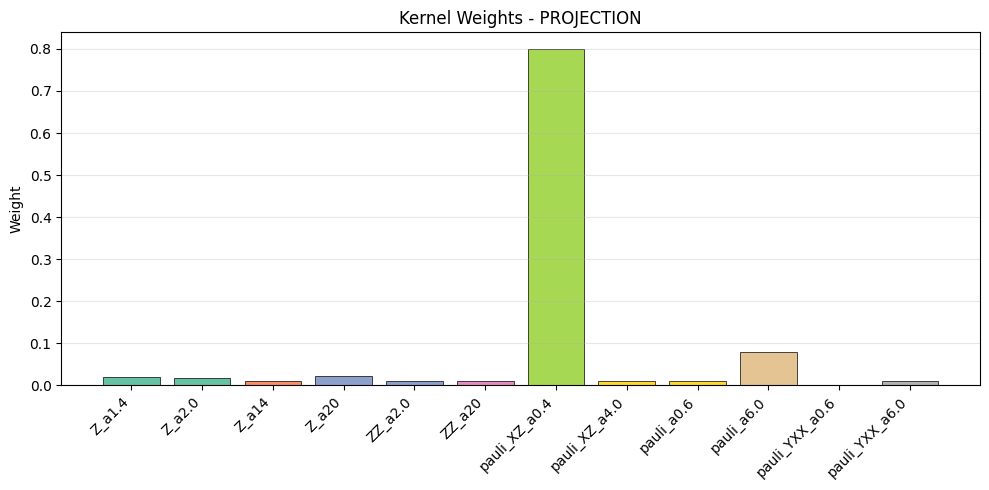

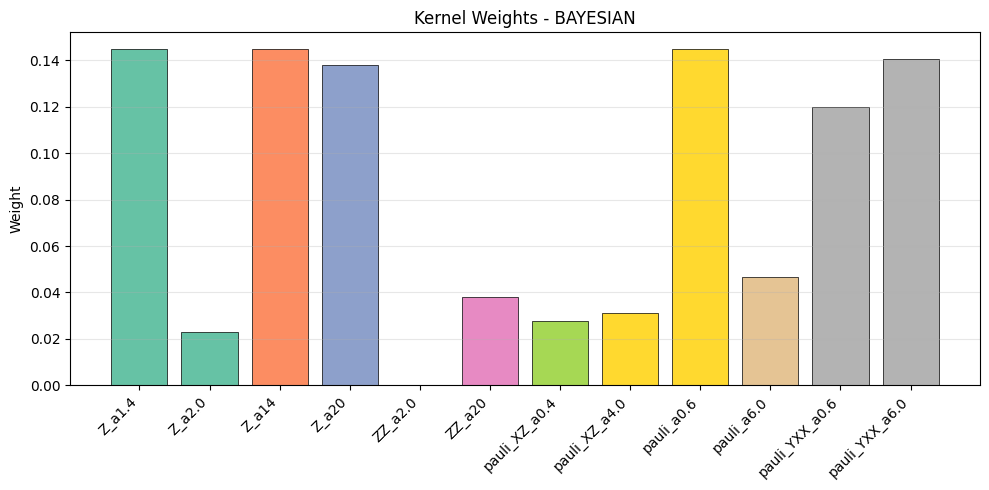

: 

In [ ]:
# Visualisation des poids par méthode
for method, weights in all_weights.items():
    plot_weights(weights, kernel_names=kernel_names, title=f'Kernel Weights - {method.upper()}')